In [22]:
import pandas as pd

df = pd.read_csv("heart.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [23]:
print("Dataset Shape:")
print(df.shape)

print("\nDataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
display(df.describe())

Dataset Shape:
(1025, 14)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca  

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [24]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 723


In [25]:
# Remove duplicate rows
df = df.drop_duplicates()

print("New Shape:", df.shape)
print("Duplicate Rows:", df.duplicated().sum())

New Shape: (302, 14)
Duplicate Rows: 0


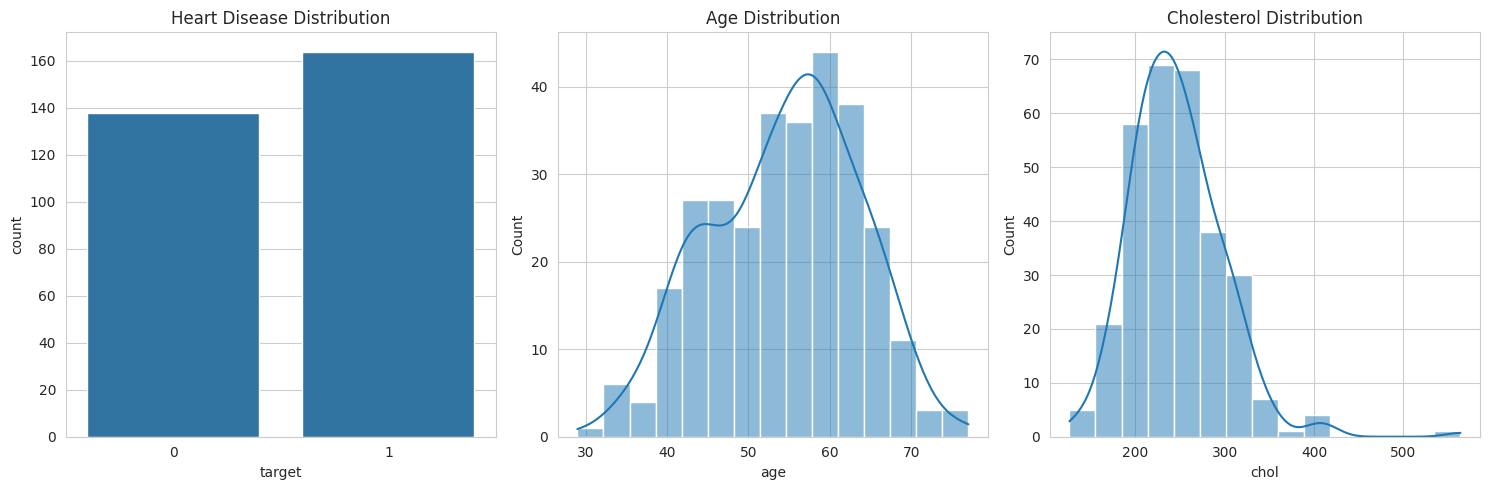

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Style
sns.set_style("whitegrid")

# Figure size
plt.figure(figsize=(15,5))

# -------------------
# Target Distribution
# -------------------
plt.subplot(1,3,1)
sns.countplot(x='target', data=df)
plt.title("Heart Disease Distribution")

# -------------------
# Age Distribution
# -------------------
plt.subplot(1,3,2)
sns.histplot(df['age'], bins=15, kde=True)
plt.title("Age Distribution")

# -------------------
# Cholesterol Distribution
# -------------------
plt.subplot(1,3,3)
sns.histplot(df['chol'], bins=15, kde=True)
plt.title("Cholesterol Distribution")

plt.tight_layout()
plt.show()

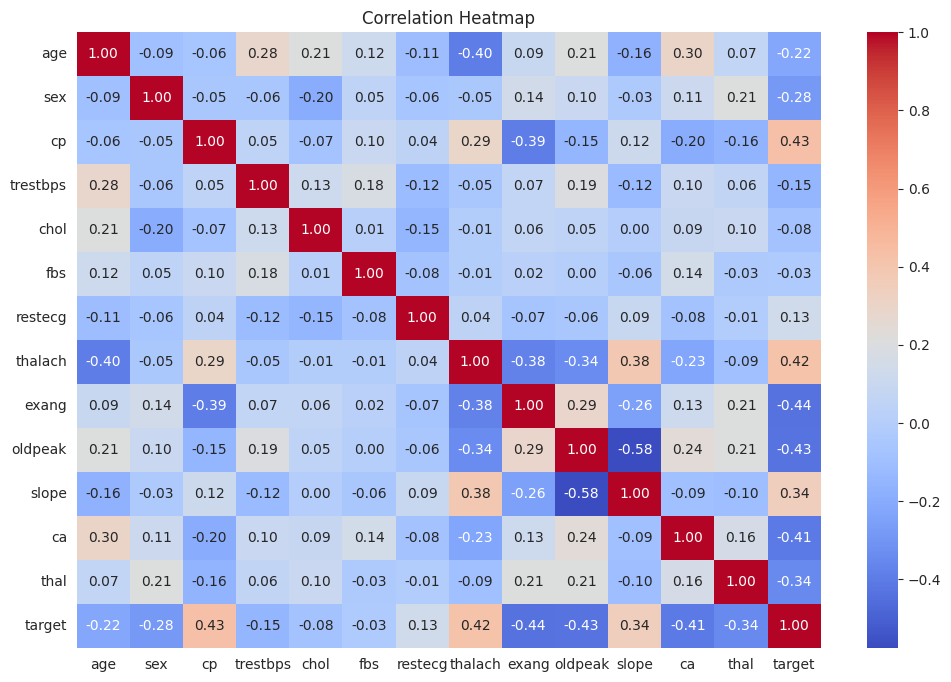

In [27]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

In [28]:
df.shape

(302, 14)

In [29]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features and Target
X = df.drop("target", axis=1)
y = df["target"]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (241, 13)
Test Shape: (61, 13)


In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

log_model = LogisticRegression()

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

accuracy_log = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", accuracy_log)

Logistic Regression Accuracy: 0.7704918032786885


In [32]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

accuracy_tree = accuracy_score(y_test, y_pred_tree)

print("Decision Tree Accuracy:", accuracy_tree)

Decision Tree Accuracy: 0.7377049180327869


In [33]:
from sklearn.metrics import classification_report

print("LOGISTIC REGRESSION")
print(classification_report(y_test, y_pred_log))

print("\n--------------------------\n")

print("DECISION TREE")
print(classification_report(y_test, y_pred_tree))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.88      0.66      0.75        32
           1       0.70      0.90      0.79        29

    accuracy                           0.77        61
   macro avg       0.79      0.78      0.77        61
weighted avg       0.79      0.77      0.77        61


--------------------------

DECISION TREE
              precision    recall  f1-score   support

           0       0.74      0.78      0.76        32
           1       0.74      0.69      0.71        29

    accuracy                           0.74        61
   macro avg       0.74      0.74      0.74        61
weighted avg       0.74      0.74      0.74        61



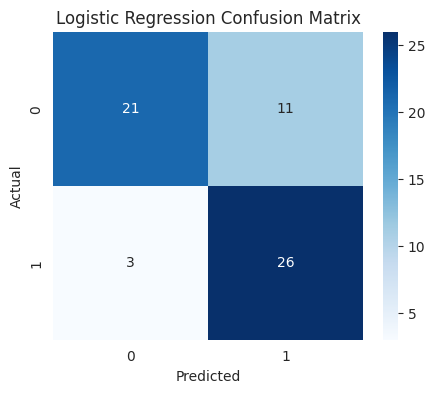

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_log,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

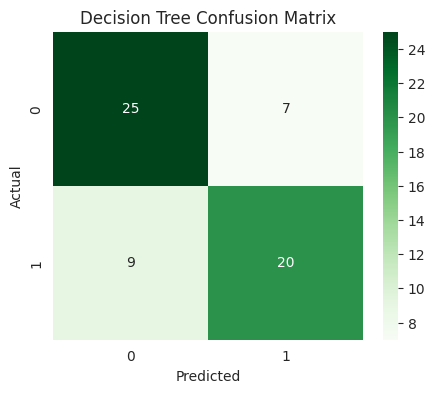

In [35]:
cm_tree = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_tree,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

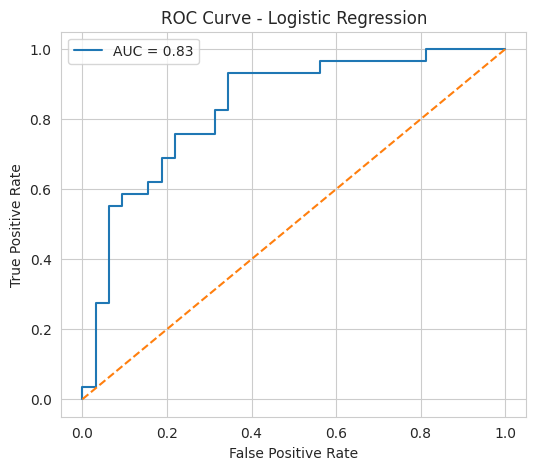

In [36]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob_log = log_model.predict_proba(X_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_log)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob_log):.2f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.show()

In [37]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# K-Means με 2 clusters
kmeans = KMeans(n_clusters=2, random_state=42)

clusters = kmeans.fit_predict(X_train_scaled)

print("Cluster Labels:")
print(clusters[:20])

Cluster Labels:
[0 1 0 0 1 0 1 1 0 1 0 0 0 1 1 0 0 0 1 1]


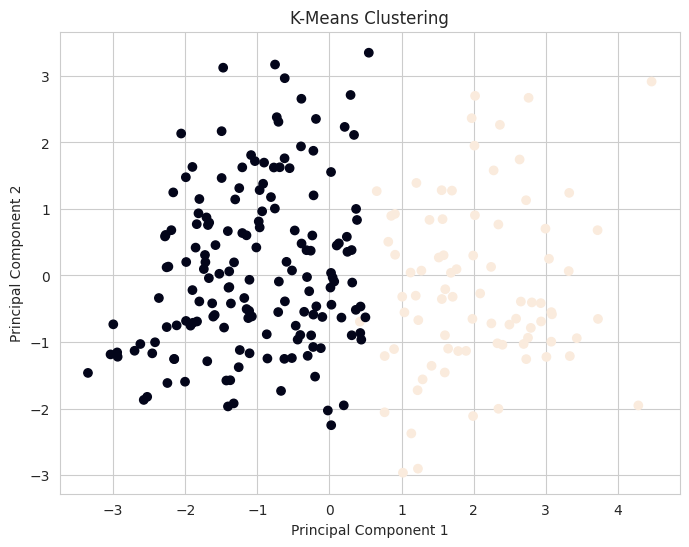

In [38]:
# PCA για απεικόνιση σε 2 διαστάσεις

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters
)

plt.title("K-Means Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [39]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_train_scaled, clusters)

print("Silhouette Score:", score)

Silhouette Score: 0.17978552494518513


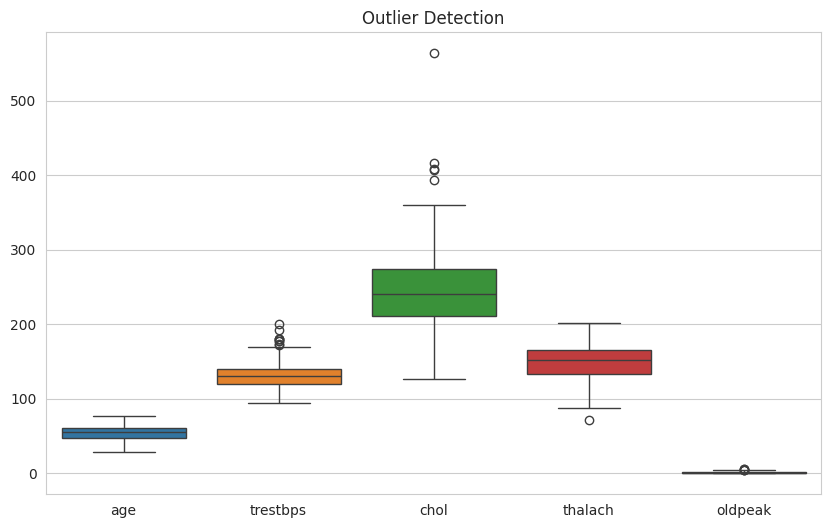

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.boxplot(data=df[['age','trestbps','chol','thalach','oldpeak']])

plt.title("Outlier Detection")
plt.show()

In [41]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[0,45,60,100],
    labels=['Young','Middle','Old']
)

print(df[['age','age_group']].head())

   age age_group
0   52    Middle
1   53    Middle
2   70       Old
3   61       Old
4   62       Old


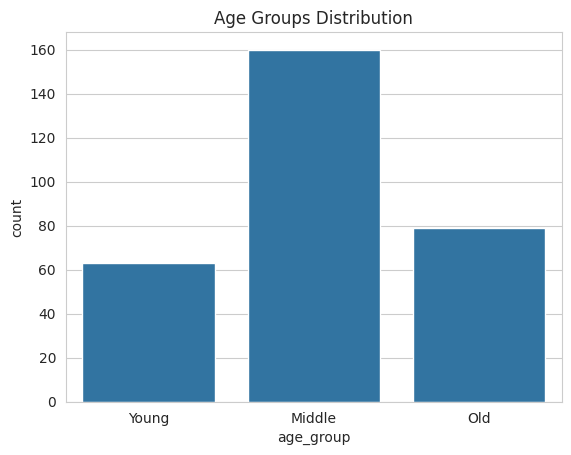

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='age_group', data=df)

plt.title("Age Groups Distribution")
plt.show()